In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from astroML.linear_model import LinearRegression
from astroML.linear_model import PolynomialRegression
from sklearn.model_selection import KFold

%config InlineBackend.figure_format='retina'
plt.rc('text', usetex=True)

/opt/anaconda3/envs/astrostat/lib/python3.13/site-packages/astroML/linear_model/linear_regression_errors.py:10: UserWarning: LinearRegressionwithErrors requires PyMC3 to be installed
  warnings.warn('LinearRegressionwithErrors requires PyMC3 to be installed')


## Time to get your hands dirty! Supernova distances and redshifts (part 1)

*(exam guidelines available [here](https://github.com/dgerosa/astrostatistics_bicocca_2026/blob/main/exams.md))*


Measuring the cosmological relationship between distance and redshift is at the heart of the entire field of cosmology and allowed, among other things, the discovery of dark energy! At high redshifts, this is done with Type Ia Supernova which are standard (or better, standardizable) candles.

This is a [Nobel prize](https://www.nobelprize.org/prizes/physics/2011/riess/facts/) plot by [Riess et al](https://iopscience.iop.org/article/10.1086/300499)

![Screen%20Shot%202022-05-01%20at%2010.48.48.png](attachment:Screen%20Shot%202022-05-01%20at%2010.48.48.png)

Let's recall the definition of magnitude and the distance modulus (ah! the astronomers...)

$$
\mu = m-M =  5 \log_{10}\left(\frac{d_L}{\rm pc}\right) - 5
$$

Here is the Hubble diagram for Type Ia supernovae (which are standard candels). The lines show the predictions for cosmologies with varying amounts of Ωm and ΩΛ. The observed points all lie above the line for a universe with zero Λ. The lower panel, with the slope caused by the inverse square law taken out, shows the difference between the predictions more clearly and shows why a model with ΩΛ > 0 is favored. 

####  Tasks

- First, explore fitting this data with the tecniques we have seen.
- Start from linear regression and polynomial regression
- For the case of  polynomial regression, just fit many of them for now.
- Let's bet based on intuition! Which fit is the best?
- In what cases are you underfitting the data?
- In what cases are you overfitting the data?
- Now split the data into training and validation sets
- Implement a cross-validation procedure
- Pick the best!
- Does it agree with our bets?

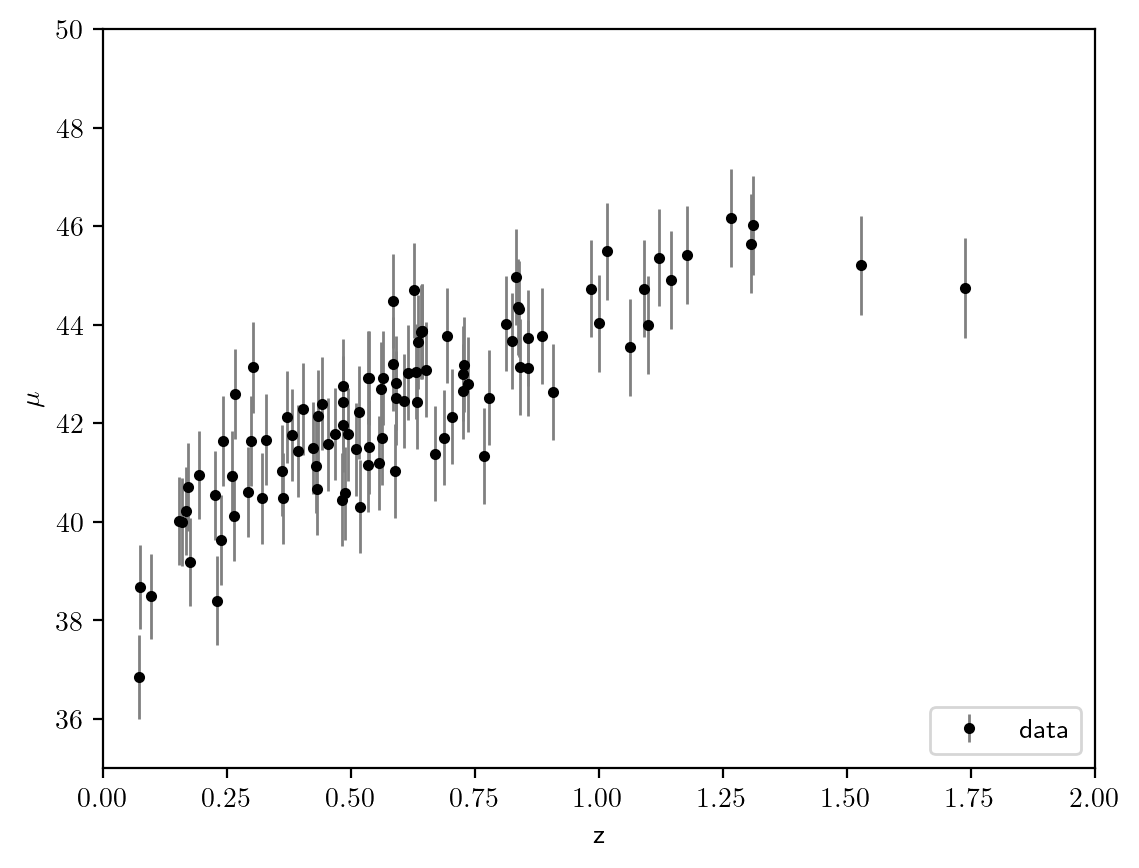

In [2]:
from astroML.datasets import generate_mu_z
z_sample, mu_sample, dmu = generate_mu_z(100, random_state=1234) # YOU CANNOT CHANGE THIS

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel(r"$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50);

In [3]:
X = z_sample[:,np.newaxis]
y = mu_sample
y_err = dmu
Xgrid = np.linspace(0., 2., 1000)[:,np.newaxis]

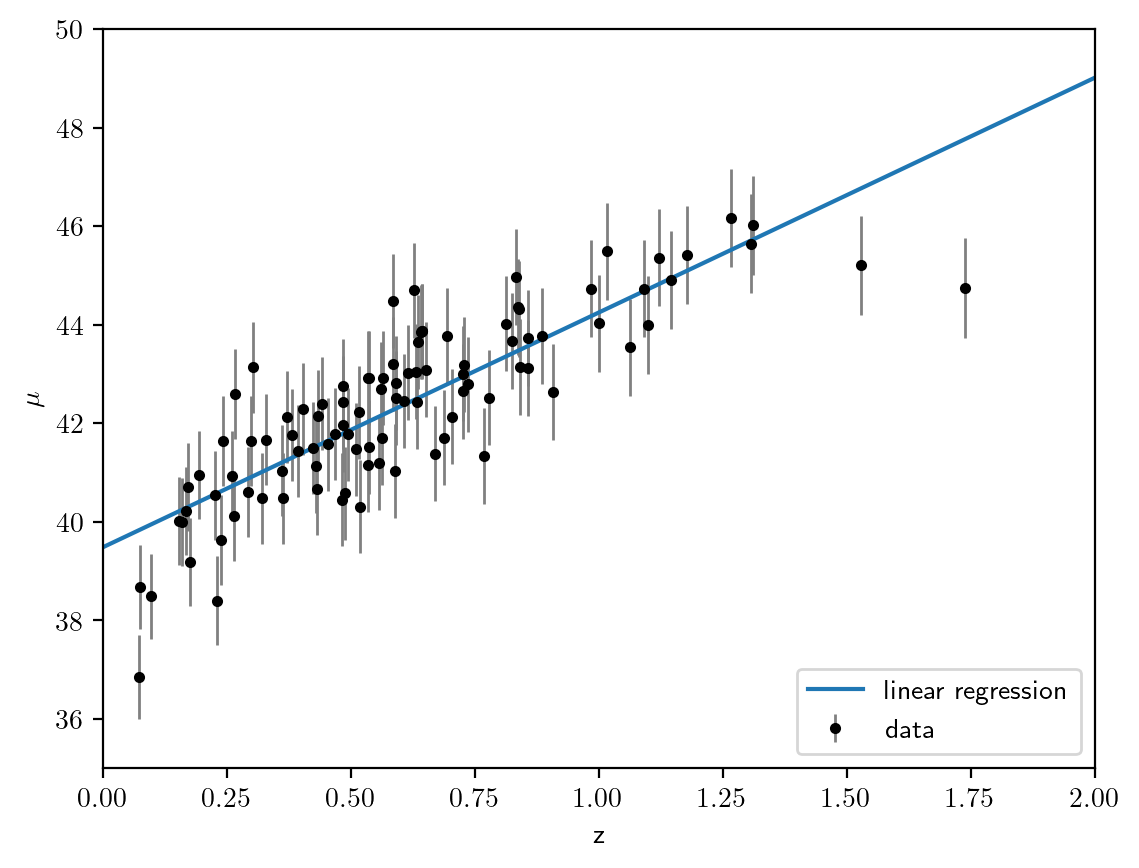

In [4]:
lin_reg = LinearRegression()
lin_reg.fit(X, y, y_err)
y_pred = lin_reg.predict(Xgrid)

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.plot(Xgrid, y_pred, label = 'linear regression')
plt.xlabel("z")
plt.ylabel(r"$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50);

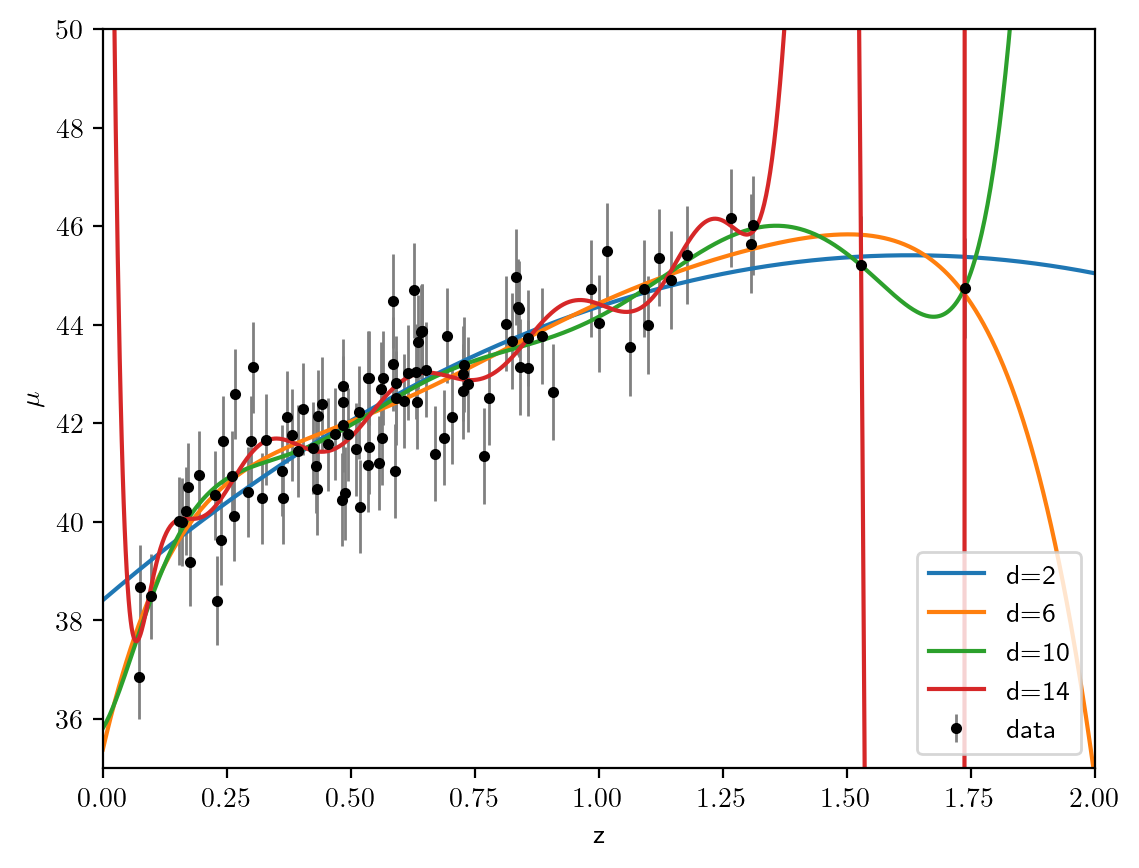

In [5]:
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel(r"$\mu$")
plt.xlim(0,2)
plt.ylim(35,50);

for d in np.arange(1,15)[1::4]:

    model = PolynomialRegression(d)
    model.fit(X, y, y_err)
    y_pred = model.predict(Xgrid)

    plt.plot(Xgrid, y_pred, label=f'd={d}')

plt.legend(loc='lower right')

d = 2 and d = 6 seem to be good fits -> Occam's razor: going with d = 2

- underfitting: for sure in the linear model (d=1)
- overfitting: for sure in d = 10, d = 14

In [6]:
Xtrain, Xtest, ytrain, ytest, errtrain, errtest = train_test_split(X, y, y_err, train_size=0.8)
print(Xtrain.shape, Xtest.shape)

(80, 1) (20, 1)


In [9]:
def kfold_cv(Xtrain, ytrain, errtrain, deg):

    kf = KFold(n_splits=5, shuffle=True)

    eps_cv = []
    eps_tr = []

    model = PolynomialRegression(deg)

    for train, val in kf.split(Xtrain):

        Xval = Xtrain[val]
        yval = ytrain[val]

        Xtr = Xtrain[train]
        ytr = ytrain[train]
        errtr = errtrain[train]

        model.fit(Xtr, ytr, errtr)
        ypred_tr = model.predict(Xtr)
        ypred_val = model.predict(Xval)

        eps_tr.append(np.sqrt(np.mean((ypred_tr - ytr) ** 2)))
        eps_cv.append(np.sqrt(np.mean((ypred_val - yval) ** 2)))

    return np.mean(eps_tr), np.mean(eps_cv)

In [10]:
deg_max = 15
degrees = np.arange(1, deg_max, dtype = int)

tr_loss = np.zeros(deg_max-1)
cv_loss = np.zeros_like(tr_loss)
for d in degrees:
    tr_loss[d-1], cv_loss[d-1] = kfold_cv(Xtrain, ytrain, errtrain, d) 
                    

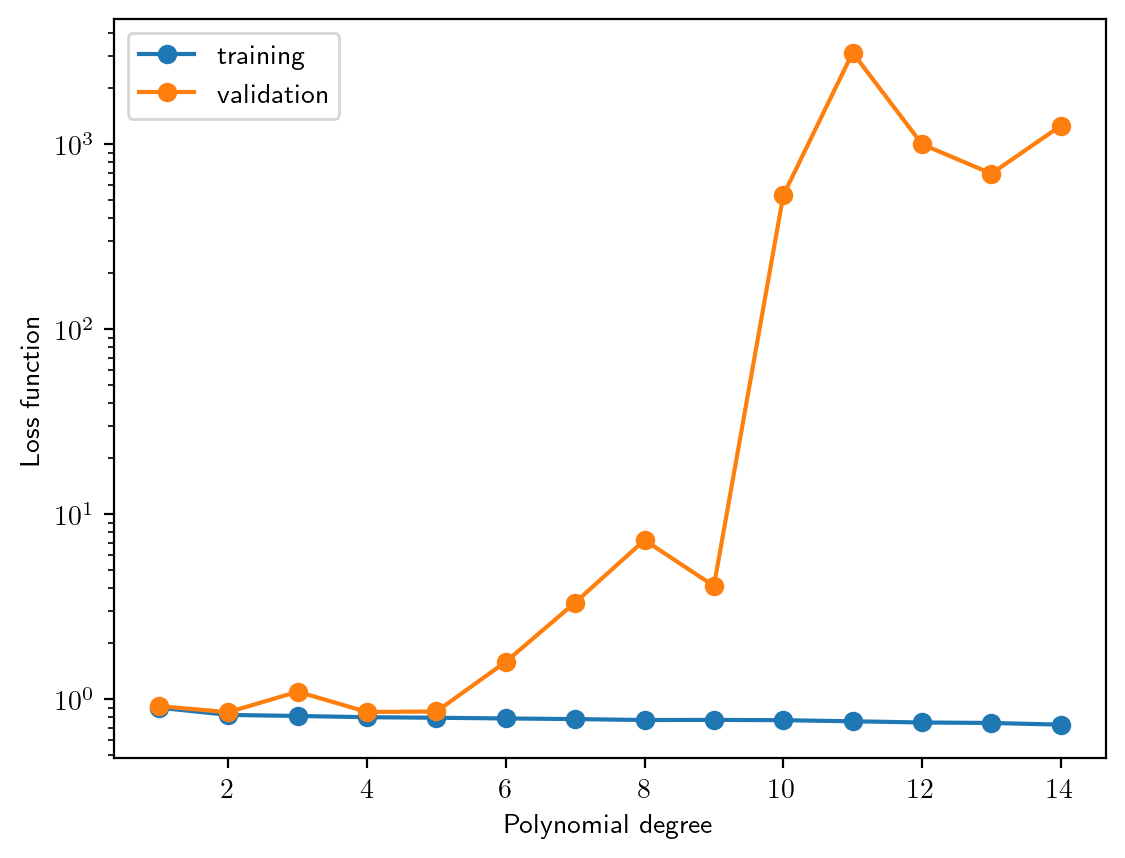

In [11]:
degrees = np.arange(1, deg_max)

plt.plot(degrees, tr_loss, label = 'training', marker = 'o')
plt.plot(degrees, cv_loss, label = 'validation', marker = 'o')
plt.yscale('log')
plt.xlabel('Polynomial degree')
plt.ylabel('Loss function')
plt.legend()

In [12]:
print(f'Best fit: polynomial of degree {np.argmin(cv_loss)+1}')

Best fit: polynomial of degree 2


In [13]:
model = PolynomialRegression(np.argmin(cv_loss)+1)
model.fit(Xtrain, ytrain, errtrain)
ypred = model.predict(Xtest)
test_err = np.sqrt(np.mean((ypred - ytest) ** 2))

In [14]:
print('Best model coefficients:', model.coef_)
print('Test error:', test_err)

Best model coefficients: [38.57929405  8.11179515 -2.38684369]
Test error: 1.168597560554838
